# 08 - Final Model Explainability

            Mục tiêu:

            - Đọc feature importance của final CatBoost.
            - Kiểm tra model có học đúng insight không.
            - Gom feature importance theo nhóm nghiệp vụ.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [2]:
FI_PATH = (
    PROJECT_ROOT
    / "data"
    / "reports"
    / "catboost_tuning"
    / "cat_tune_depth7_l2_8_lr003_iter700"
    / "feature_importance.csv"
)

print("FI_PATH exists:", FI_PATH.exists())

fi = pd.read_csv(FI_PATH)
display(fi.head(30))

FI_PATH exists: True


,feature,importance
0,numeric__mcc_entropy_30d,13.674755
1,numeric__night_ratio_30d,10.538663
2,numeric__spending_trend,9.237068
3,numeric__log_amount_to_max_30d,9.147954
4,numeric__distinct_countries_30d,8.867071
5,numeric__amount_z_30d,7.850833
6,numeric__decline_rate_30d,4.255852
7,numeric__device_diversity_30d,4.087863
8,numeric__credit_util_today,3.908415
9,numeric__log_mean_amount_30d,2.236788


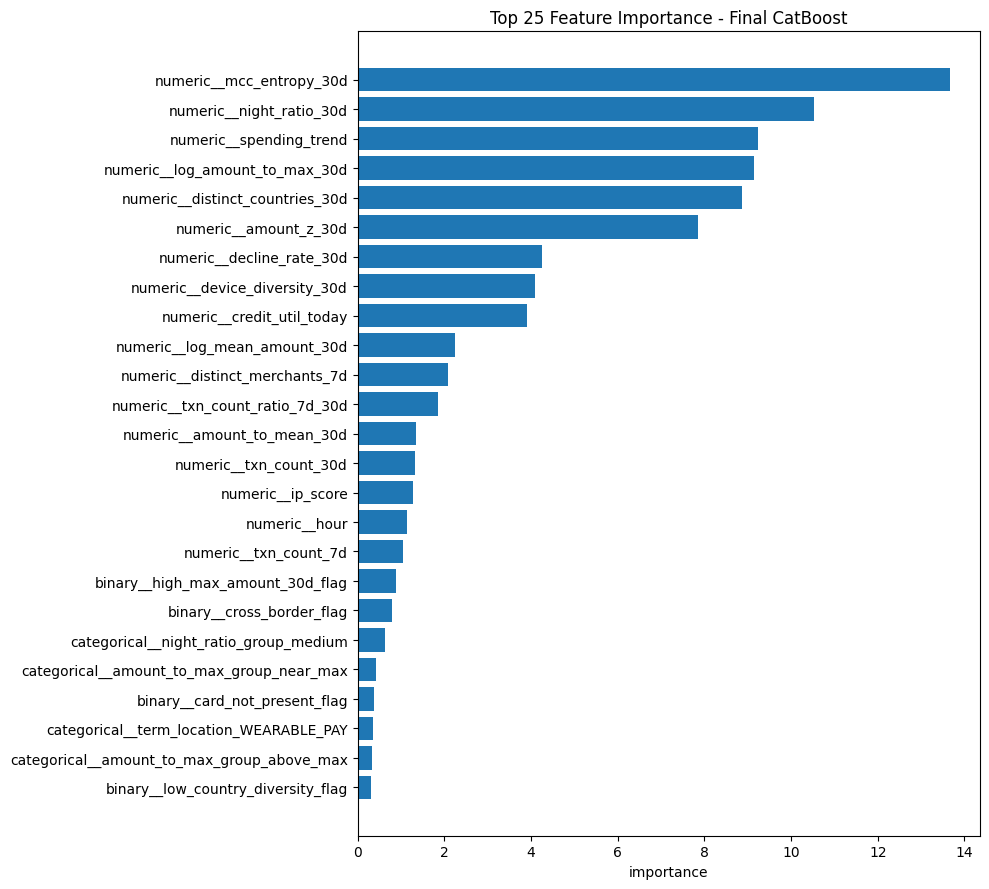

In [3]:
top = fi.sort_values("importance", ascending=False).head(25)

plt.figure(figsize=(10, 9))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Top 25 Feature Importance - Final CatBoost")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

In [4]:
def map_insight_group(feature: str) -> str:
    f = feature.lower()

    if "amount" in f:
        return "Amount anomaly"
    if "mcc_entropy" in f or "mcc" in f:
        return "MCC behavior"
    if "night" in f or "time_period" in f or "hour" in f:
        return "Time/night behavior"
    if "spending_trend" in f:
        return "Spending trend"
    if "country" in f or "cross_border" in f or "countries" in f:
        return "Country behavior"
    if (
        "decline" in f
        or "ip_score" in f
        or "device" in f
        or "chargeback" in f
        or "credit" in f
    ):
        return "Risk/technical"
    if "txn_count" in f or "velocity" in f:
        return "Velocity"
    if (
        "payment" in f
        or "auth" in f
        or "card" in f
        or "pin" in f
        or "term_location" in f
    ):
        return "Payment/auth context"

    return "Other"


fi["insight_group"] = fi["feature"].apply(map_insight_group)

group_summary = (
    fi.groupby("insight_group")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(group_summary)

,insight_group,importance
0,Amount anomaly,22.431525
1,Risk/technical,14.485164
2,MCC behavior,13.933660
3,Time/night behavior,13.704508
4,Country behavior,11.260999
5,Spending trend,9.410378
6,Other,5.323570
7,Payment/auth context,4.916674
8,Velocity,4.533522


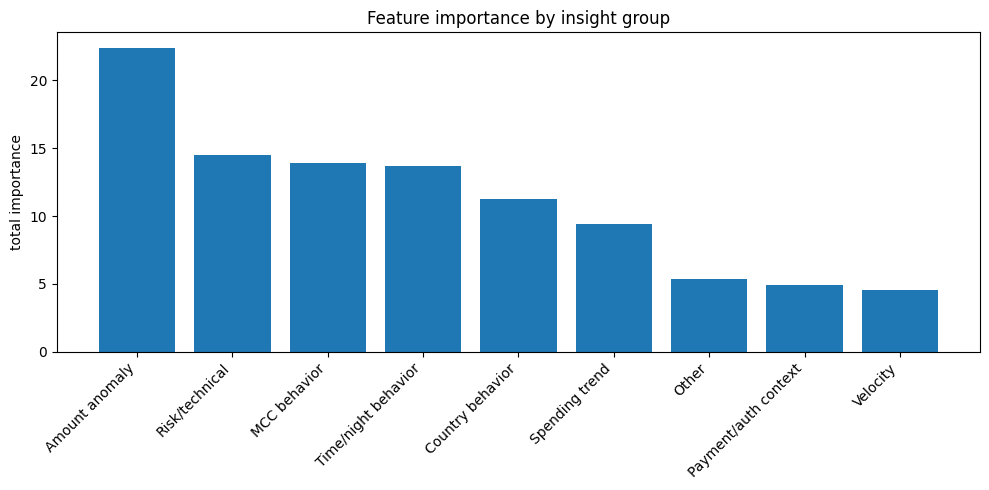

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(group_summary["insight_group"], group_summary["importance"])
plt.title("Feature importance by insight group")
plt.ylabel("total importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
# Kiểm tra model có phụ thuộc trực tiếp vào MCC category không
mcc_rows = fi[fi["feature"].str.contains("mcc", case=False, na=False)]
display(mcc_rows)

,feature,importance,insight_group
0,numeric__mcc_entropy_30d,13.674755,MCC behavior
43,binary__very_low_mcc_entropy_flag,0.192931,MCC behavior
92,binary__low_mcc_entropy_flag,0.065974,MCC behavior
155,categorical__mcc_infrequent_sklearn,0.000000,MCC behavior


## Kết luận cần ghi sau khi chạy

            - Top feature có khớp insight giai đoạn 3 không?
            - Model có phụ thuộc vào mã MCC cụ thể không?
            - Feature importance không cho biết chiều tác động; muốn biết chiều tác động cần SHAP/PDP hoặc tham khảo Logistic Regression coefficient.